In [24]:
# import packages
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
# load final/cleaned data
df = pd.read_csv(Path("../data/processed/bank_model_ready.csv"))
df.shape
df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,0.693147,999,0.0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,0.693147,999,0.0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,0.693147,999,0.0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,0.693147,999,0.0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,0.693147,999,0.0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


In [46]:
cols_to_drop = [
    "treatment",
    "outcome",
    "duration",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

month_cols = [c for c in df.columns if c.startswith("month_")]
dow_cols = [c for c in df.columns if c.startswith("day_of_week_")]

X = df.drop(columns=cols_to_drop + month_cols + dow_cols)

In [48]:
X.head()

,age,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,poutcome_nonexistent,poutcome_success
0,56,0.693147,999,0.0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,57,0.693147,999,0.0,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,37,0.693147,999,0.0,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,40,0.693147,999,0.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,56,0.693147,999,0.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [49]:
# define variables
T = df["treatment"]
Y = df["outcome"]

In [51]:
# Logistic Regression pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=5000,
        penalty="l2",
        C=0.1  # add regularization
    ))
])

In [52]:
# fit model + predict
pipe.fit(X, T)
df["propensity"] = pipe.predict_proba(X)[:, 1]

c:\Users\marvi\GitHub Projects\bank-marketing-causal-analysis\bankmarketing\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [53]:
# inspect propensity scores
df["propensity"].describe()

count    41188.000000
mean         0.634744
std          0.149804
min          0.257818
25%          0.530093
50%          0.616810
75%          0.703754
max          0.999878
Name: propensity, dtype: float64

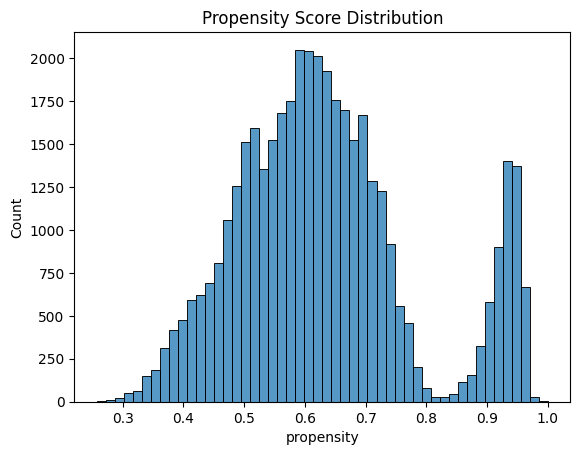

In [54]:
# visualize propensity scores
sns.histplot(df["propensity"], bins=50)
plt.title("Propensity Score Distribution")
plt.show()

In [55]:
# clip extreme propensities
df["propensity"] = np.clip(df["propensity"], 0.01, 0.99)

In [56]:
# compute stablized IPW weights
p_t = T.mean()

df["weight"] = np.where(
    T == 1,
    p_t / df["propensity"],
    (1 - p_t) / (1 - df["propensity"])
)

df["weight"].describe()

count    41188.000000
mean         1.004674
std          0.560715
min          0.492133
25%          0.762489
50%          0.940358
75%          1.098487
max         12.070322
Name: weight, dtype: float64

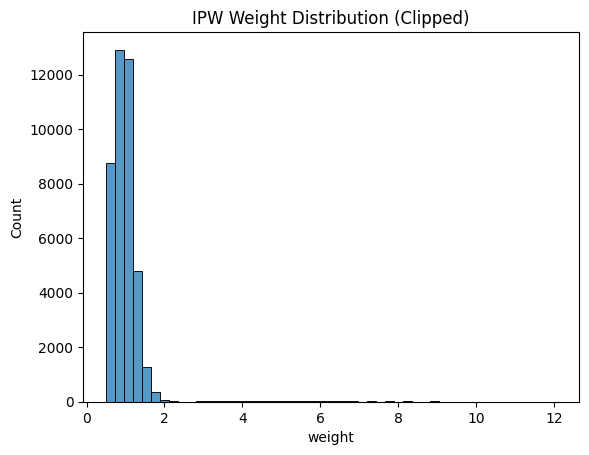

In [57]:
# visualize weight distributions
sns.histplot(df["weight"], bins=50)
plt.title("IPW Weight Distribution (Clipped)")
plt.show()

In [58]:
# estimate ATE
ate_ipw = (
    np.average(Y[T == 1], weights=df.loc[T == 1, "weight"]) -
    np.average(Y[T == 0], weights=df.loc[T == 0, "weight"])
)

ate_ipw

np.float64(0.05282448232201925)

In [59]:
# compare ATE to Naive ATE
ate_naive = Y[T == 1].mean() - Y[T == 0].mean()

print("Naive ATE:", ate_naive)
print("IPW ATE:", ate_ipw)

Naive ATE: 0.09506285642083914
IPW ATE: 0.05282448232201925


In [60]:
# recheck post weight balankce
smd_post = []

for col in X.columns:
    smd_val = smd_weighted(df, col)
    smd_post.append(abs(smd_val))

max_smd = max(smd_post)
max_smd

np.float64(0.0423327292466143)